# 03 - Mission Range and Altitude Study

The `analysis/cfg-case-study/` directory contains Archer Midnight configurations for multiple mission ranges and cruise altitudes. This notebook compares sizing results across these cases to show how range and altitude affect the aircraft design.

This is a **design space exploration**: we vary 2 parameters while keeping the config fixed, showing the sensitivity to these values.

| Case | Range | Cruise Altitude | Key Physics |
|------|-------|----------------|-------------|
| 1500-30 | 30 miles | 1,500 ft | Baseline, shortest mission |
| 1500-45 | 45 miles | 1,500 ft | 50% longer cruise segment |
| 1500-60 | 60 miles | 1,500 ft | 100% longer cruise, approaching range limits |
| 3000-30 | 30 miles | 3,000 ft | Lower air density at cruise altitude |
| 3000-45 | 45 miles | 3,000 ft | Combined range + altitude effects |
| 3000-60 | 60 miles | 3,000 ft | Most demanding case |

In [ ]:
import sys
sys.path.append('../../')
from evtol.aircraft import Aircraft

ac = Aircraft('../Archer_Midnight.json')

## Load All Configurations

We load the six Archer Midnight cases: three mission ranges at two cruise altitudes.

In [3]:
base = '../../analysis/cfg-case-study'

cases = {
    '1500 ft / 30 mi': Aircraft(f'{base}/low-altitude-1500-ft/archer-midnight/30-miles/Archer-Midnight-1500-30.json'),
    '1500 ft / 45 mi': Aircraft(f'{base}/low-altitude-1500-ft/archer-midnight/45-miles/Archer-Midnight-1500-45.json'),
    '1500 ft / 60 mi': Aircraft(f'{base}/low-altitude-1500-ft/archer-midnight/60-miles/Archer-Midnight-1500-60.json'),
    '3000 ft / 30 mi': Aircraft(f'{base}/high-altitude-3000-ft/archer-midnight/30-miles/Archer-Midnight-3000-30.json'),
    '3000 ft / 45 mi': Aircraft(f'{base}/high-altitude-3000-ft/archer-midnight/45-miles/Archer-Midnight-3000-45.json'),
    '3000 ft / 60 mi': Aircraft(f'{base}/high-altitude-3000-ft/archer-midnight/60-miles/Archer-Midnight-3000-60.json'),
}

print(f"Loaded {len(cases)} configurations.")

Loaded 6 configurations.


## MTOW Convergence Comparison

Each configuration uses the same initial MTOW guess (3,175 kg). The converged MTOW varies with mission energy requirements. Longer range means more cruise energy, heavier battery, and higher converged MTOW. The mass snowball effect amplifies range differences.

In [4]:
print(f"{'Case':<20s} {'Converged MTOW (kg)':>20s} {'Iterations':>12s}")
print("-" * 54)

convergence = {}
for label, ac in cases.items():
    final_mtow, history = ac._iterate_mtow()
    convergence[label] = (final_mtow, len(history))
    print(f"{label:<20s} {final_mtow:>20.2f} {len(history):>12d}")

Case                  Converged MTOW (kg)   Iterations
------------------------------------------------------
1500 ft / 30 mi                   1995.81           18
1500 ft / 45 mi                   2231.79           20
1500 ft / 60 mi                   2504.90           22
3000 ft / 30 mi                   1950.12           19
3000 ft / 45 mi                   2180.52           20
3000 ft / 60 mi                   2448.44           23


## Effect of Range on Sizing (1,500 ft)

At a fixed altitude, increasing mission range extends the cruise segment duration, requiring more energy and a heavier battery.

The key relationship: cruise energy scales linearly with range ($E_{cruise} = P_{cruise} \times t_{cruise}$ and $t_{cruise} = d/V$), but the **total aircraft mass** grows nonlinearly.

In [5]:
ranges_mi = [30, 45, 60]
low_labels = ['1500 ft / 30 mi', '1500 ft / 45 mi', '1500 ft / 60 mi']

print(f"{'Range':<10s} {'Cruise (s)':>10s} {'Batt (kg)':>10s} {'Empty (kg)':>10s} {'Energy (kWh)':>12s} {'L/D':>6s}")
print("-" * 60)
for r, label in zip(ranges_mi, low_labels):
    ac = cases[label]
    primary_energy = sum([
        ac.depart_taxi_energy_kw_hr, ac.hover_climb_energy_kw_hr,
        ac.trans_climb_energy_kw_hr, ac.depart_proc_energy_kw_hr,
        ac.accel_climb_energy_kw_hr, ac.cruise_energy_kw_hr,
        ac.decel_descend_energy_kw_hr, ac.arrive_proc_energy_kw_hr,
        ac.trans_descend_energy_kw_hr, ac.hover_descend_energy_kw_hr,
        ac.arrive_taxi_energy_kw_hr,
    ])
    print(f"{r:<10d} {ac.mission.cruise_s:>10.0f} {ac.battery_mass_kg:>10.2f} "
          f"{ac.empty_mass_kg:>10.2f} {primary_energy:>12.2f} {ac.cruise_l_p_d:>6.2f}")

Range      Cruise (s)  Batt (kg) Empty (kg) Energy (kWh)    L/D
------------------------------------------------------------
30                558     286.36    1255.45        37.03   8.19
45                918     437.05    1340.74        60.88   8.72
60               1278     608.88    1442.02        88.00   9.24


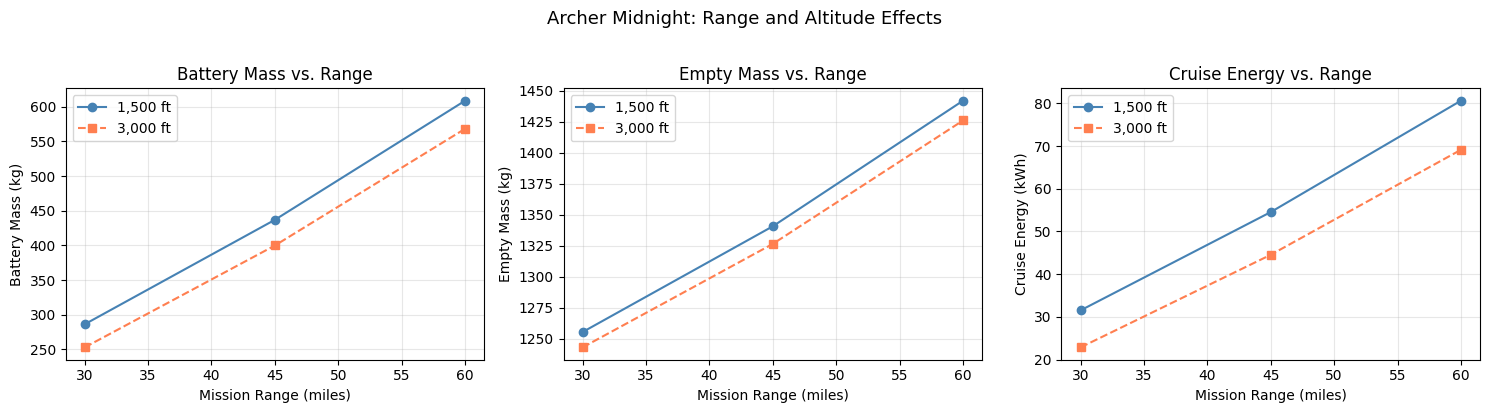

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Battery mass vs range
batt_low = [cases[l].battery_mass_kg for l in low_labels]
batt_high = [cases[l.replace('1500', '3000')].battery_mass_kg for l in low_labels]
axes[0].plot(ranges_mi, batt_low, 'o-', color='steelblue', label='1,500 ft')
axes[0].plot(ranges_mi, batt_high, 's--', color='coral', label='3,000 ft')
axes[0].set_xlabel('Mission Range (miles)')
axes[0].set_ylabel('Battery Mass (kg)')
axes[0].set_title('Battery Mass vs. Range')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Empty mass vs range
empty_low = [cases[l].empty_mass_kg for l in low_labels]
empty_high = [cases[l.replace('1500', '3000')].empty_mass_kg for l in low_labels]
axes[1].plot(ranges_mi, empty_low, 'o-', color='steelblue', label='1,500 ft')
axes[1].plot(ranges_mi, empty_high, 's--', color='coral', label='3,000 ft')
axes[1].set_xlabel('Mission Range (miles)')
axes[1].set_ylabel('Empty Mass (kg)')
axes[1].set_title('Empty Mass vs. Range')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Cruise energy vs range
cruise_e_low = [cases[l].cruise_energy_kw_hr for l in low_labels]
cruise_e_high = [cases[l.replace('1500', '3000')].cruise_energy_kw_hr for l in low_labels]
axes[2].plot(ranges_mi, cruise_e_low, 'o-', color='steelblue', label='1,500 ft')
axes[2].plot(ranges_mi, cruise_e_high, 's--', color='coral', label='3,000 ft')
axes[2].set_xlabel('Mission Range (miles)')
axes[2].set_ylabel('Cruise Energy (kWh)')
axes[2].set_title('Cruise Energy vs. Range')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Archer Midnight: Range and Altitude Effects', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Effect of Altitude

Higher cruise altitude means lower air density, which has competing effects:

- **Cruise**: Lower $\rho$ -> higher true airspeed for same indicated airspeed -> mixed drag effects
- **Climb/Descend**: Longer duration to reach higher altitude -> more energy

Compare the 1,500 ft and 3,000 ft cases at the same 30-mile range:

In [7]:
low = cases['1500 ft / 30 mi']
high = cases['3000 ft / 30 mi']

print(f"{'Parameter':<35s} {'1,500 ft':>12s} {'3,000 ft':>12s}")
print("=" * 61)
print(f"{'Air density at cruise (kg/m^3)':<35s} {low.environ.air_density_max_alt_kg_p_m3:>12.3f} {high.environ.air_density_max_alt_kg_p_m3:>12.3f}")
print(f"{'Cruise L/D':<35s} {low.cruise_l_p_d:>12.2f} {high.cruise_l_p_d:>12.2f}")
print(f"{'Cruise CL':<35s} {low.cruise_cl:>12.4f} {high.cruise_cl:>12.4f}")
print(f"{'Cruise CD':<35s} {low.cruise_cd:>12.6f} {high.cruise_cd:>12.6f}")
print(f"{'Hover shaft power (kW)':<35s} {low.hover_shaft_power_kw:>12.2f} {high.hover_shaft_power_kw:>12.2f}")
print(f"{'Cruise shaft power (kW)':<35s} {low.cruise_avg_shaft_power_kw:>12.2f} {high.cruise_avg_shaft_power_kw:>12.2f}")
print()
print(f"{'Hover climb duration (s)':<35s} {low.mission.hover_climb_s:>12.0f} {high.mission.hover_climb_s:>12.0f}")
print(f"{'Accel climb duration (s)':<35s} {low.mission.accel_climb_s:>12.0f} {high.mission.accel_climb_s:>12.0f}")
print(f"{'Cruise duration (s)':<35s} {low.mission.cruise_s:>12.0f} {high.mission.cruise_s:>12.0f}")
print()
print(f"{'Battery mass (kg)':<35s} {low.battery_mass_kg:>12.2f} {high.battery_mass_kg:>12.2f}")
print(f"{'Empty mass (kg)':<35s} {low.empty_mass_kg:>12.2f} {high.empty_mass_kg:>12.2f}")

Parameter                               1,500 ft     3,000 ft
Air density at cruise (kg/m^3)             1.175        1.120
Cruise L/D                                  8.19         8.07
Cruise CL                                 0.5492       0.5492
Cruise CD                               0.067076     0.068063
Hover shaft power (kW)                    395.92       382.40
Cruise shaft power (kW)                   182.97       175.03

Hover climb duration (s)                       6           12
Accel climb duration (s)                      72          144
Cruise duration (s)                          558          423

Battery mass (kg)                         286.36       253.03
Empty mass (kg)                          1255.45      1243.08


## Mass Fraction Comparison Across All Cases

The stacked bar chart below shows how the mass budget shifts as mission demands increase. As range grows, the battery fraction increases at the expense of the payload fraction.

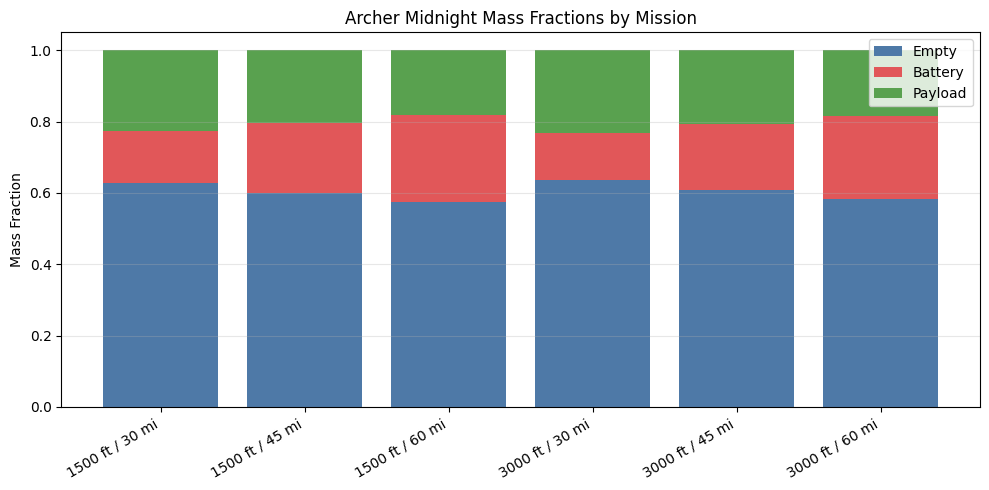

In [8]:
labels = list(cases.keys())
empty_fracs = [cases[l].empty_mass_kg / cases[l].max_takeoff_mass_kg for l in labels]
batt_fracs = [cases[l].battery_mass_kg / cases[l].max_takeoff_mass_kg for l in labels]
payload_fracs = [cases[l].payload_kg / cases[l].max_takeoff_mass_kg for l in labels]

x = range(len(labels))

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x, empty_fracs, label='Empty', color='#4e79a7')
ax.bar(x, batt_fracs, bottom=empty_fracs, label='Battery', color='#e15759')
ax.bar(x, payload_fracs,
       bottom=[e + b for e, b in zip(empty_fracs, batt_fracs)],
       label='Payload', color='#59a14f')

ax.set_xticks(list(x))
ax.set_xticklabels(labels, rotation=30, ha='right')
ax.set_ylabel('Mass Fraction')
ax.set_title('Archer Midnight Mass Fractions by Mission')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Summary

This comparative study reveals several sizing trends for the Archer Midnight:

- **Longer range** increases cruise duration -> more energy -> heavier battery -> higher converged MTOW. The relationship is **nonlinear** due to the mass snowball effect.
- **Higher altitude** extends climb/descend segments while the cruise drag effects depend on the specific aerodynamic regime.
- **Battery mass fraction** grows with range, leaving less margin for payload or structural mass
- At extreme ranges, the design may fail to converge (battery fraction exceeds feasible limits), this defines the **maximum feasible range** for a given vehicle configuration
